# Import Basic Libraries

In [380]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reading Dataset

In [381]:
df = pd.read_csv("IMDb Movies India.csv",encoding='latin-1')
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [382]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [383]:
df.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [384]:
df.duplicated().sum()

np.int64(6)

In [385]:
df.drop_duplicates(inplace=True)

In [386]:
df=df.dropna(subset=['Rating'])
df.dropna(inplace=True)

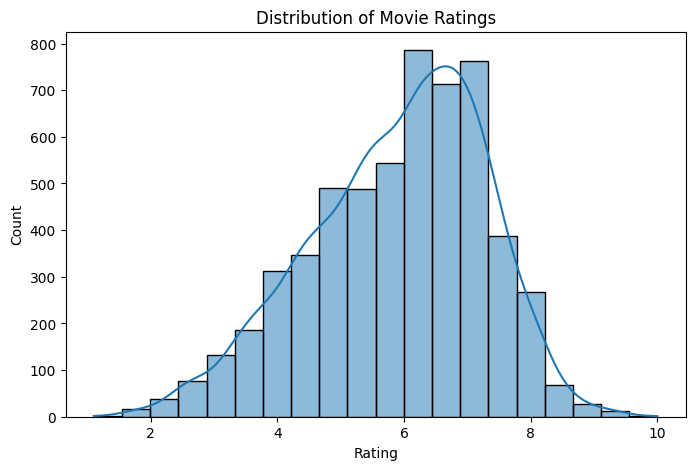

In [387]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df["Rating"], bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.show()

In [388]:
df["Year"] = df["Year"].str.extract(r"(\d{4})")
df["Year"] = df["Year"].astype(int)

In [389]:
df["Duration"] = df["Duration"].str.extract(r"(\d+) min")
df["Duration"] = df["Duration"].astype(int)

In [390]:
df["Rating"].describe()

count    5659.000000
mean        5.898533
std         1.381165
min         1.100000
25%         5.000000
50%         6.100000
75%         6.900000
max        10.000000
Name: Rating, dtype: float64

In [391]:
df = df[(df["Rating"] >= 0) & (df["Rating"] <= 10)]
df['Genre']=df["Genre"].fillna("Unknown")

In [392]:
cols=['Genre','Director','Actor 1','Actor 2','Actor 3']

for i in cols:
    df[i]=df[i].str.strip()

In [393]:
genre_dummies = df["Genre"].str.get_dummies(sep=',')
df = pd.concat([df, genre_dummies], axis=1)

df.columns = df.columns.str.strip()
df = df.loc[:, ~df.columns.duplicated()]
df["Votes"] = df["Votes"].str.replace(",", "", regex=False)
df["Votes"] = df["Votes"].astype(int)

In [394]:
df["LogVotes"] = np.log1p(df["Votes"])
director_freq = df["Director"].value_counts().to_dict()
df["Director_encoded"] = df["Director"].map(director_freq)

In [395]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              5659 non-null   object 
 1   Year              5659 non-null   int64  
 2   Duration          5659 non-null   int64  
 3   Genre             5659 non-null   object 
 4   Rating            5659 non-null   float64
 5   Votes             5659 non-null   int64  
 6   Director          5659 non-null   object 
 7   Actor 1           5659 non-null   object 
 8   Actor 2           5659 non-null   object 
 9   Actor 3           5659 non-null   object 
 10  Action            5659 non-null   int64  
 11  Adventure         5659 non-null   int64  
 12  Biography         5659 non-null   int64  
 13  Comedy            5659 non-null   int64  
 14  Crime             5659 non-null   int64  
 15  Drama             5659 non-null   int64  
 16  Family            5659 non-null   int64  
 17 

In [396]:
actor_freq = df["Actor 1"].value_counts().to_dict()
df["Actor1_encoded"] = df["Actor 1"].map(actor_freq)

In [397]:
actor_freq = df["Actor 2"].value_counts().to_dict()
df["Actor2_encoded"] = df["Actor 2"].map(actor_freq)

In [398]:
actor_freq = df["Actor 3"].value_counts().to_dict()
df["Actor3_encoded"] = df["Actor 3"].map(actor_freq)

In [399]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,...,Thriller,War,Western,Animation,Documentary,LogVotes,Director_encoded,Actor1_encoded,Actor2_encoded,Actor3_encoded
1,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,...,0,0,0,0,0,2.197225,1,2,1,1
3,#Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,...,0,0,0,0,0,3.583519,1,5,1,2
5,...Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,...,0,0,0,0,0,6.719013,15,18,15,11
6,...Yahaan,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,...,0,1,0,0,0,6.991177,6,20,3,8
8,?: A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,...,1,0,0,0,0,5.789960,1,1,6,1


In [400]:
df['Age']=2026-df['Year']

In [401]:
df.drop(['Name','Genre','Director','Votes','Year','Actor 1','Actor 2','Actor 3'],axis=1,inplace=True) 

In [402]:
df.head()

,Duration,Rating,Action,Adventure,Biography,Comedy,Crime,Drama,Family,Fantasy,...,War,Western,Animation,Documentary,LogVotes,Director_encoded,Actor1_encoded,Actor2_encoded,Actor3_encoded,Age
1,109,7.0,0,0,0,0,0,0,0,0,...,0,0,0,0,2.197225,1,2,1,1,7
3,110,4.4,0,0,0,0,0,0,0,0,...,0,0,0,0,3.583519,1,5,1,2,7
5,147,4.7,0,0,0,0,0,1,0,0,...,0,0,0,0,6.719013,15,18,15,11,29
6,142,7.4,0,0,0,0,0,0,0,0,...,1,0,0,0,6.991177,6,20,3,8,21
8,82,5.6,0,0,0,0,0,0,0,0,...,0,0,0,0,5.789960,1,1,6,1,14


In [403]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

In [404]:
x=df.drop('Rating',axis=1)
y=df['Rating']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [405]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Duration          5659 non-null   int64  
 1   Rating            5659 non-null   float64
 2   Action            5659 non-null   int64  
 3   Adventure         5659 non-null   int64  
 4   Biography         5659 non-null   int64  
 5   Comedy            5659 non-null   int64  
 6   Crime             5659 non-null   int64  
 7   Drama             5659 non-null   int64  
 8   Family            5659 non-null   int64  
 9   Fantasy           5659 non-null   int64  
 10  History           5659 non-null   int64  
 11  Horror            5659 non-null   int64  
 12  Music             5659 non-null   int64  
 13  Musical           5659 non-null   int64  
 14  Mystery           5659 non-null   int64  
 15  News              5659 non-null   int64  
 16  Romance           5659 non-null   int64  
 17 

In [406]:
x_train_sc=scaler.fit_transform(x_train)
x_test_sc=scaler.transform(x_test)

# Linear Regression Model

In [407]:
from sklearn.linear_model import LinearRegression

lnr = LinearRegression()

lnr.fit(x_train_sc, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [408]:
y_pred_lnr=lnr.predict(x_test_sc)
y_pred_lnr

array([5.90177988, 5.47861077, 5.53836491, ..., 5.8910858 , 6.00191601,
       6.60826853], shape=(1132,))

# Random Forest Regressor

In [409]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200,random_state=42)

In [410]:
rf.fit(x_train,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [411]:
y_pred_rf=rf.predict(x_test)
y_pred_rf

array([4.8895, 6.183 , 4.375 , ..., 5.7915, 5.843 , 6.4865], shape=(1132,))

# XGBoost Regressor

In [412]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)

In [413]:
xgb.fit(x_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [414]:
y_pred_xgb = xgb.predict(x_test)
y_pred_xgb

array([5.2213593, 6.137696 , 4.6171064, ..., 5.6547866, 6.462887 ,
       6.1738405], shape=(1132,), dtype=float32)

# Evaluation

In [415]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [416]:
def evaluate_model(name, y_true, y_pred):
    print(f"📊 {name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))
    print("-"*40)

In [417]:
evaluate_model("Linear Regression", y_test, y_pred_lnr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

📊 Linear Regression
MAE: 0.9751503338353117
RMSE: 1.2350602575243042
R2 Score: 0.17624999394330765
----------------------------------------
📊 Random Forest
MAE: 0.8489752650176678
RMSE: 1.1313583165643692
R2 Score: 0.30877492511796134
----------------------------------------
📊 XGBoost
MAE: 0.8183988983555311
RMSE: 1.0934893799114285
R2 Score: 0.3542739965776157
----------------------------------------


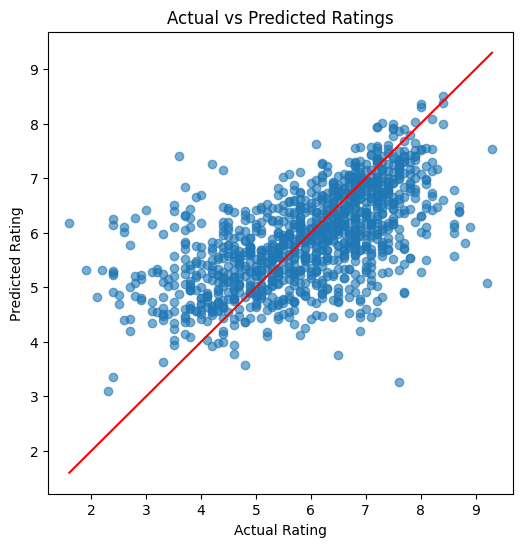

In [418]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings")
plt.show()

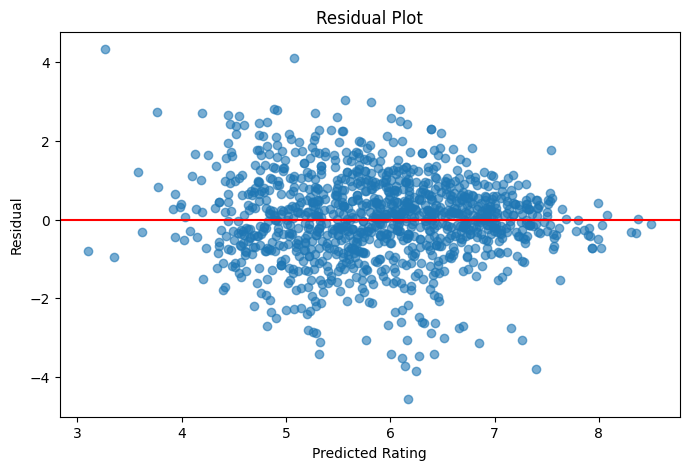

In [419]:
residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))
plt.scatter(y_pred_xgb, residuals, alpha=0.6)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Rating")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

### Overall the best model we got XGBoost for Regression where low MAE, RMSE and High R² Values are recorded

# Task Completed 👍